In [1]:
#importing libraries for the project
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
pd.set_option('display.max_columns', 100)     # show all columns
pd.set_option('display.float_format', '{:.4f}'.format)  # clean decimal display
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
print('Libraries loaded successfully')

/Users/shivamverma/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/application_train.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

Dataset shape: (307511, 122)
Rows: 307,511  |  Columns: 122


In [3]:
# Target distribution  Analysis
target_counts = df['TARGET'].value_counts()
target_pct    = df['TARGET'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count'      : target_counts,
    'Percentage' : target_pct.round(2)
})
target_summary.index = ['Non-Default (0)', 'Default (1)']
print('Target Variable Distribution')
print('='*40)
print(target_summary)

default_rate = df['TARGET'].mean() * 100
print(f'\nOverall Default Rate: {default_rate:.2f}%')
print(f'Class Imbalance Ratio: 1 : {(1 - df["TARGET"].mean()) / df["TARGET"].mean():.1f}')

Target Variable Distribution
                  Count  Percentage
Non-Default (0)  282686     91.9300
Default (1)       24825      8.0700

Overall Default Rate: 8.07%
Class Imbalance Ratio: 1 : 11.4


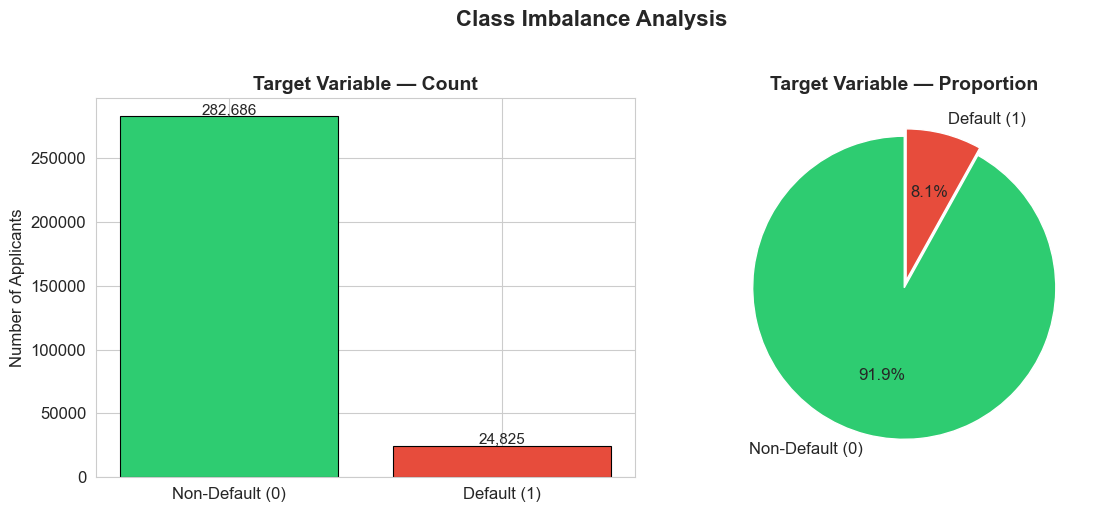

Chart saved to outputs folder 


In [4]:
# ── Visualise target distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']  # green = good, red = bad
axes[0].bar(['Non-Default (0)', 'Default (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Variable — Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=['Non-Default (0)', 'Default (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Target Variable — Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs folder ')

In [5]:
# ── Missing value summary ─────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing %'      : (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type'      : df.dtypes
})

# Only show columns that have missing values, sorted by % missing
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total columns with missing values: {len(missing)} out of {df.shape[1]}')
print(f'\nTop 20 columns by missing %:')
print(missing.head(20).to_string())

Total columns with missing values: 67 out of 122

Top 20 columns by missing %:
                          Missing Count  Missing % Data Type
COMMONAREA_MEDI                  214865    69.8700   float64
COMMONAREA_AVG                   214865    69.8700   float64
COMMONAREA_MODE                  214865    69.8700   float64
NONLIVINGAPARTMENTS_MEDI         213514    69.4300   float64
NONLIVINGAPARTMENTS_MODE         213514    69.4300   float64
NONLIVINGAPARTMENTS_AVG          213514    69.4300   float64
FONDKAPREMONT_MODE               210295    68.3900    object
LIVINGAPARTMENTS_MODE            210199    68.3500   float64
LIVINGAPARTMENTS_MEDI            210199    68.3500   float64
LIVINGAPARTMENTS_AVG             210199    68.3500   float64
FLOORSMIN_MODE                   208642    67.8500   float64
FLOORSMIN_MEDI                   208642    67.8500   float64
FLOORSMIN_AVG                    208642    67.8500   float64
YEARS_BUILD_MODE                 204488    66.5000   float64
YEARS_

In [6]:
# ── Categorise missing severity ───────────────────────────────────────────────
# Industry rule of thumb for scorecard development:
# > 80% missing → likely drop (too little data to be useful)
# 30-80% missing → treat carefully, may still have predictive power
# < 30% missing → impute and keep

high_missing   = missing[missing['Missing %'] > 80]
medium_missing = missing[(missing['Missing %'] > 30) & (missing['Missing %'] <= 80)]
low_missing    = missing[missing['Missing %'] <= 30]

print(f'High missing (>80%):    {len(high_missing)} columns — likely candidates for dropping')
print(f'Medium missing (30-80%): {len(medium_missing)} columns — review individually')
print(f'Low missing (<30%):     {len(low_missing)} columns — impute and keep')

High missing (>80%):    0 columns — likely candidates for dropping
Medium missing (30-80%): 50 columns — review individually
Low missing (<30%):     17 columns — impute and keep


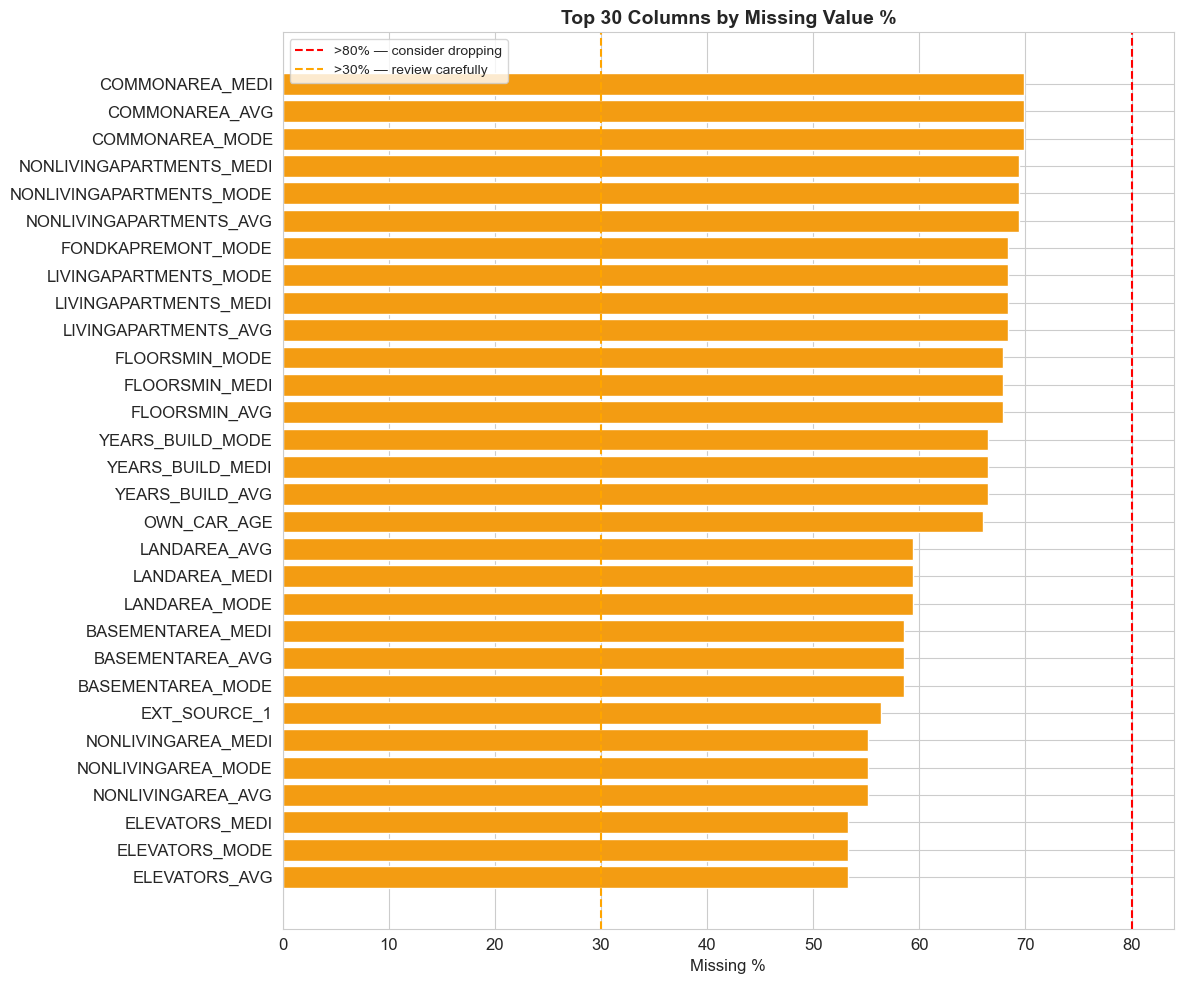

Chart saved ✓


In [7]:
# ── Visualise missing values ──────────────────────────────────────────────────
top_missing = missing.head(30)

fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ['#e74c3c' if x > 80 else '#f39c12' if x > 30 else '#3498db'
              for x in top_missing['Missing %']]

bars = ax.barh(top_missing.index, top_missing['Missing %'], color=colors_bar, edgecolor='white')
ax.set_xlabel('Missing %', fontsize=12)
ax.set_title('Top 30 Columns by Missing Value %', fontsize=14, fontweight='bold')
ax.axvline(x=80, color='red',    linestyle='--', linewidth=1.5, label='>80% — consider dropping')
ax.axvline(x=30, color='orange', linestyle='--', linewidth=1.5, label='>30% — review carefully')
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [8]:
key_num_cols = [
    'AMT_INCOME_TOTAL',    # applicant income
    'AMT_CREDIT',          # loan amount requested
    'AMT_ANNUITY',         # annual repayment amount
    'AMT_GOODS_PRICE',     # price of goods for which loan is taken
    'DAYS_BIRTH',          # age in days (negative number — will convert)
    'DAYS_EMPLOYED',       # employment duration in days (negative)
    'DAYS_REGISTRATION',   # days since registration changed
    'DAYS_ID_PUBLISH',     # days since ID was published
    'CNT_CHILDREN',        # number of children
    'CNT_FAM_MEMBERS'      # family members count
]

# Basic stats for key columns
print('Key Numerical Variables — Summary Statistics')
print('='*60)
df[key_num_cols].describe().T.round(2)

Key Numerical Variables — Summary Statistics


,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0000,168797.9200,237123.1500,25650.0000,112500.0000,147150.0000,202500.0000,117000000.0000
AMT_CREDIT,307511.0000,599026.0000,402490.7800,45000.0000,270000.0000,513531.0000,808650.0000,4050000.0000
AMT_ANNUITY,307499.0000,27108.5700,14493.7400,1615.5000,16524.0000,24903.0000,34596.0000,258025.5000
AMT_GOODS_PRICE,307233.0000,538396.2100,369446.4600,40500.0000,238500.0000,450000.0000,679500.0000,4050000.0000
DAYS_BIRTH,307511.0000,-16037.0000,4363.9900,-25229.0000,-19682.0000,-15750.0000,-12413.0000,-7489.0000
DAYS_EMPLOYED,307511.0000,63815.0500,141275.7700,-17912.0000,-2760.0000,-1213.0000,-289.0000,365243.0000
DAYS_REGISTRATION,307511.0000,-4986.1200,3522.8900,-24672.0000,-7479.5000,-4504.0000,-2010.0000,0.0000
DAYS_ID_PUBLISH,307511.0000,-2994.2000,1509.4500,-7197.0000,-4299.0000,-3254.0000,-1720.0000,0.0000
CNT_CHILDREN,307511.0000,0.4200,0.7200,0.0000,0.0000,0.0000,1.0000,19.0000
CNT_FAM_MEMBERS,307509.0000,2.1500,0.9100,1.0000,2.0000,2.0000,3.0000,20.0000


In [9]:
df['AGE_YEARS']        = -df['DAYS_BIRTH'] / 365
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365

# IMPORTANT: DAYS_EMPLOYED has a known data issue
# Value 365243 = missing/unemployed code (not actual employment of 1000 years!)
# This is a well-known quirk of this dataset
print(f'Anomalous DAYS_EMPLOYED (365243) count: {(df["DAYS_EMPLOYED"] == 365243).sum():,}')
print(f'This represents: {(df["DAYS_EMPLOYED"] == 365243).mean()*100:.1f}% of records')

# Flag and replace with NaN — will handle in preprocessing notebook
df['EMPLOYMENT_YEARS'] = df['EMPLOYMENT_YEARS'].replace(365243 / 365 * -1, np.nan)
df.loc[df['DAYS_EMPLOYED'] == 365243, 'EMPLOYMENT_YEARS'] = np.nan

print('\nAge range after conversion:')
print(f'  Min: {df["AGE_YEARS"].min():.1f} years')
print(f'  Max: {df["AGE_YEARS"].max():.1f} years')
print(f'  Mean: {df["AGE_YEARS"].mean():.1f} years')

Anomalous DAYS_EMPLOYED (365243) count: 55,374
This represents: 18.0% of records

Age range after conversion:
  Min: 20.5 years
  Max: 69.1 years
  Mean: 43.9 years


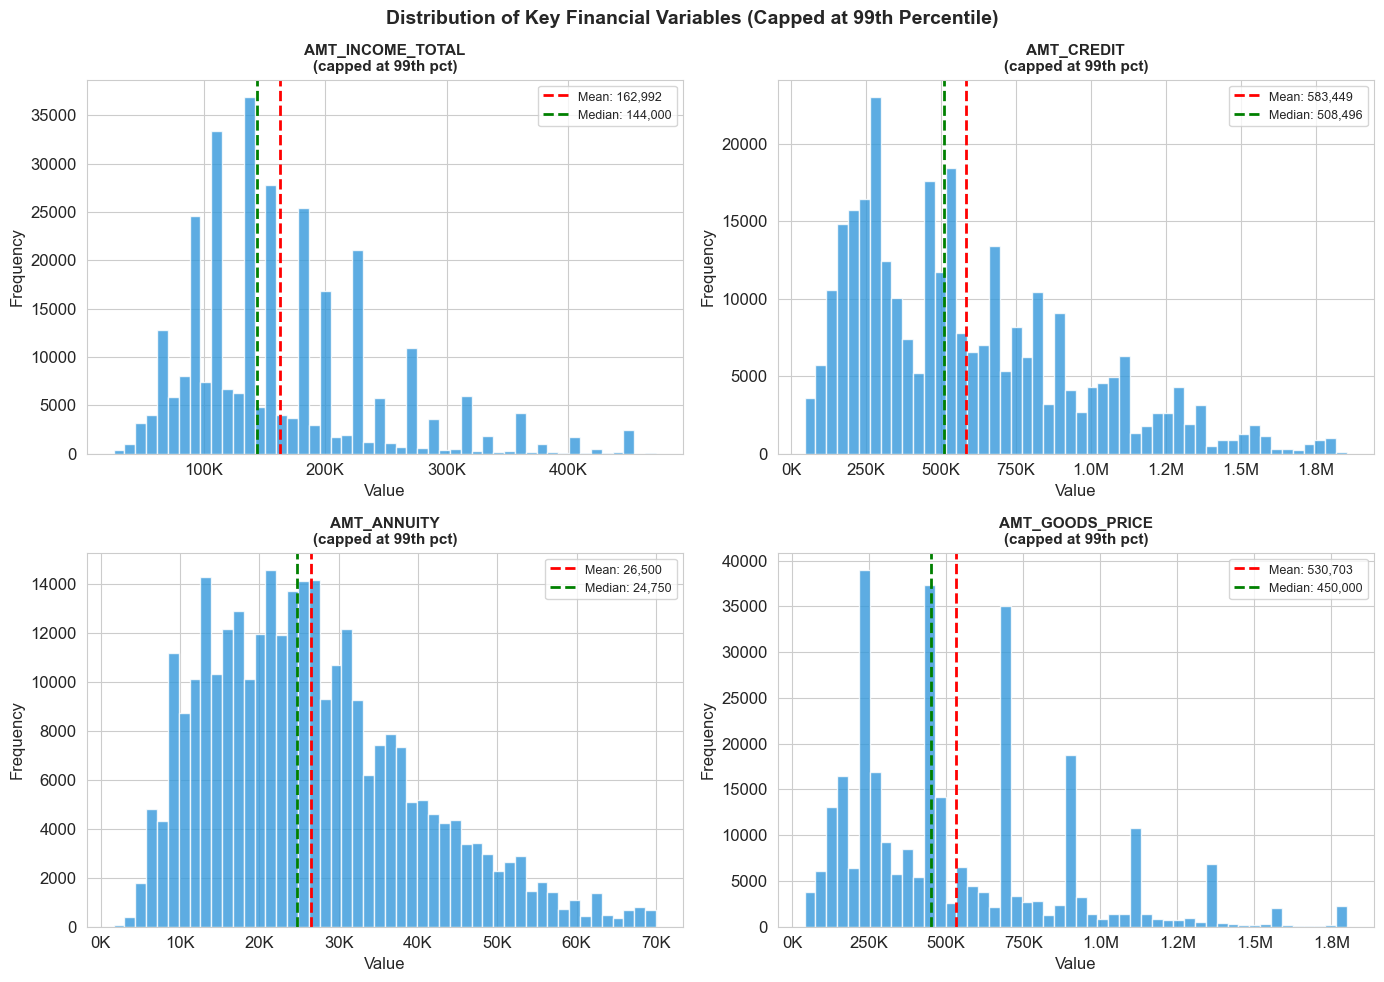

In [10]:
# ── Distribution plots for key financial variables ────────────────────────────
financial_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(financial_cols):
    # Cap at 99th percentile for better visualisation (extreme outliers squash the chart)
    cap_val = df[col].quantile(0.99)
    data    = df[df[col] <= cap_val][col].dropna()

    axes[i].hist(data, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=2, label=f'Mean: {data.mean():,.0f}')
    axes[i].axvline(data.median(), color='green',  linestyle='--', linewidth=2, label=f'Median: {data.median():,.0f}')
    axes[i].set_title(f'{col}\n(capped at 99th pct)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    axes[i].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

plt.suptitle('Distribution of Key Financial Variables (Capped at 99th Percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_financial_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

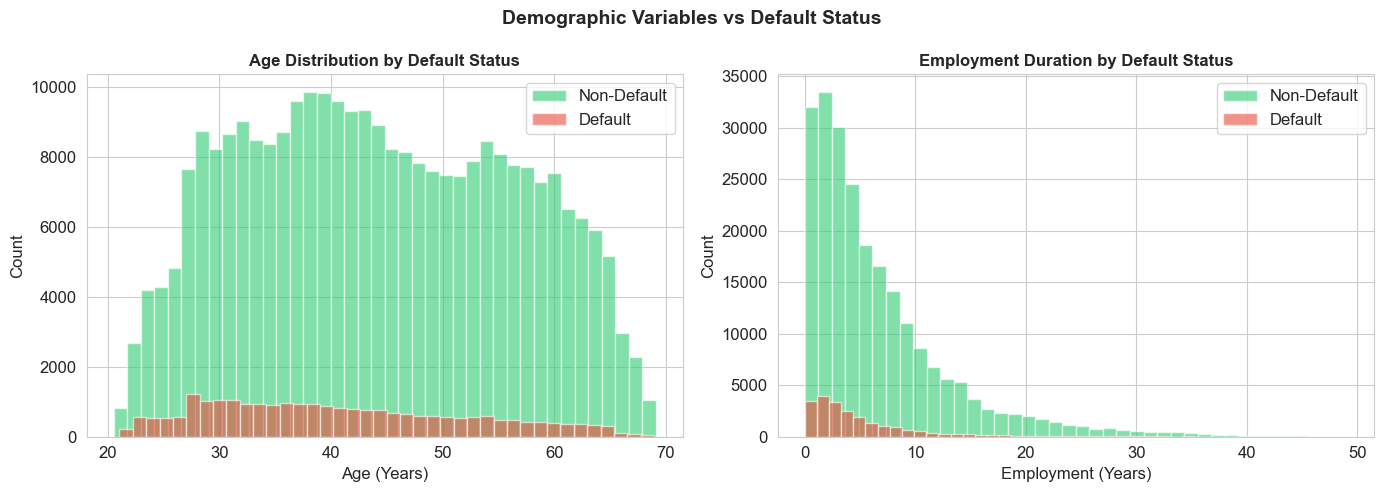

In [11]:
# ── Age and Employment distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by target
df[df['TARGET'] == 0]['AGE_YEARS'].hist(ax=axes[0], bins=40, alpha=0.6, color='#2ecc71', label='Non-Default')
df[df['TARGET'] == 1]['AGE_YEARS'].hist(ax=axes[0], bins=40, alpha=0.6, color='#e74c3c', label='Default')
axes[0].set_title('Age Distribution by Default Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Employment years distribution by target
emp_data = df[df['EMPLOYMENT_YEARS'].notna() & (df['EMPLOYMENT_YEARS'] < 50)]
emp_data[emp_data['TARGET'] == 0]['EMPLOYMENT_YEARS'].hist(ax=axes[1], bins=40, alpha=0.6, color='#2ecc71', label='Non-Default')
emp_data[emp_data['TARGET'] == 1]['EMPLOYMENT_YEARS'].hist(ax=axes[1], bins=40, alpha=0.6, color='#e74c3c', label='Default')
axes[1].set_title('Employment Duration by Default Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Employment (Years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Demographic Variables vs Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_age_employment_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Get all categorical columns ───────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Total categorical columns: {len(cat_cols)}')
print('\nColumns:', cat_cols)

Total categorical columns: 16

Columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [13]:
# ── Default rate by category — the most important EDA for credit risk ─────────
# For each categorical variable, we compute:
# 1. Count per category
# 2. Default rate per category
# High variation in default rate = high predictive power = good scorecard variable

def default_rate_by_category(df, col, target='TARGET', top_n=10):
    """Compute count, % share, and default rate per category."""
    summary = df.groupby(col)[target].agg(['count', 'sum', 'mean'])
    summary.columns = ['Count', 'Defaults', 'Default Rate']
    summary['Share %'] = (summary['Count'] / summary['Count'].sum() * 100).round(1)
    summary['Default Rate %'] = (summary['Default Rate'] * 100).round(2)
    summary = summary.sort_values('Default Rate %', ascending=False)
    return summary[['Count', 'Share %', 'Default Rate %']].head(top_n)

# Key categorical variables to examine
key_cat_cols = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

for col in key_cat_cols:
    print(f'\n{"="*55}')
    print(f'  {col}')
    print(f'{"="*55}')
    print(default_rate_by_category(df, col).to_string())


  NAME_CONTRACT_TYPE
                     Count  Share %  Default Rate %
NAME_CONTRACT_TYPE                                 
Cash loans          278232  90.5000          8.3500
Revolving loans      29279   9.5000          5.4800

  CODE_GENDER
              Count  Share %  Default Rate %
CODE_GENDER                                 
M            105059  34.2000         10.1400
F            202448  65.8000          7.0000
XNA               4   0.0000          0.0000

  NAME_INCOME_TYPE
                       Count  Share %  Default Rate %
NAME_INCOME_TYPE                                     
Maternity leave            5   0.0000         40.0000
Unemployed                22   0.0000         36.3600
Working               158774  51.6000          9.5900
Commercial associate   71617  23.3000          7.4800
State servant          21703   7.1000          5.7500
Pensioner              55362  18.0000          5.3900
Businessman               10   0.0000          0.0000
Student                 

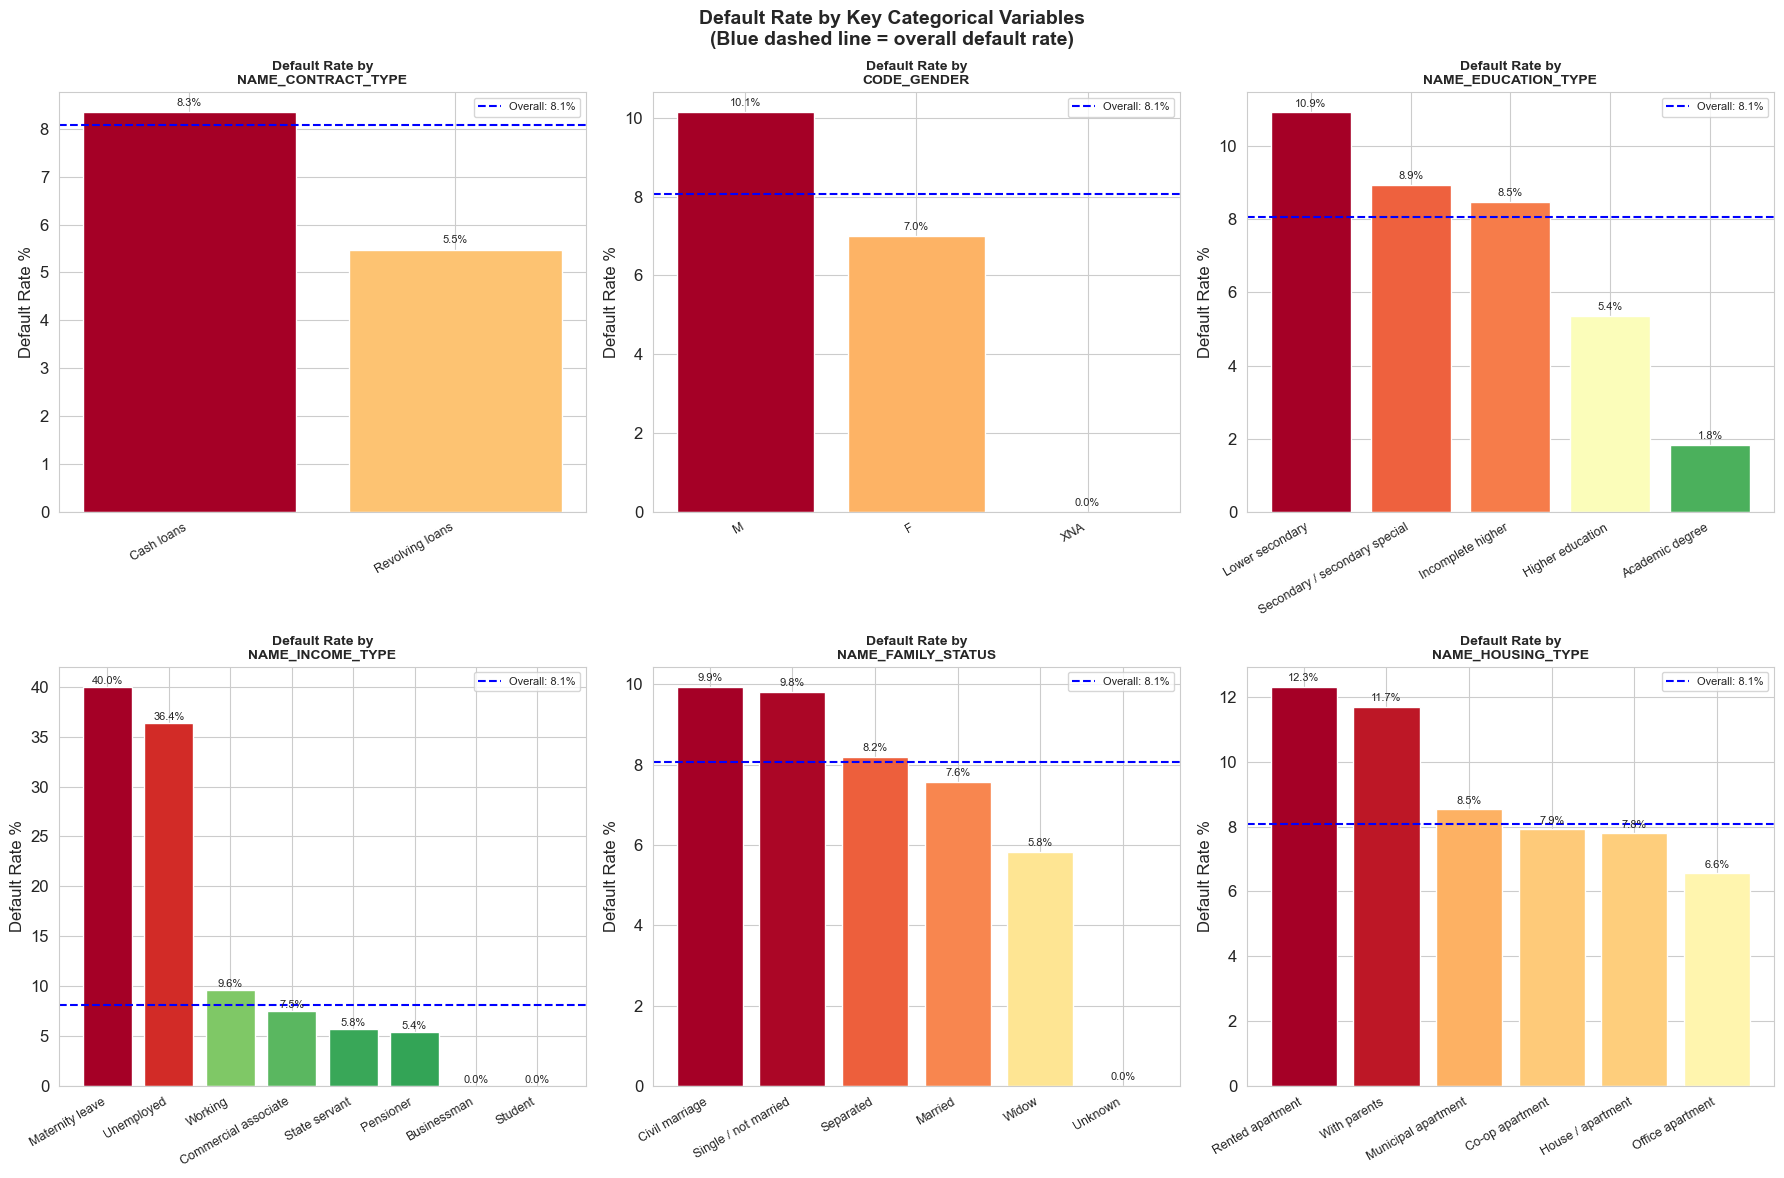

In [14]:
# ── Visualise default rate by top categorical variables ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_cols = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
    'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'
]

for i, col in enumerate(plot_cols):
    summary = df.groupby(col)['TARGET'].mean() * 100
    summary = summary.sort_values(ascending=False)

    bars = axes[i].bar(range(len(summary)), summary.values,
                       color=plt.cm.RdYlGn_r(summary.values / summary.max()),
                       edgecolor='white')
    axes[i].set_xticks(range(len(summary)))
    axes[i].set_xticklabels(summary.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'Default Rate by\n{col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Default Rate %')
    axes[i].axhline(y=df['TARGET'].mean()*100, color='blue', linestyle='--',
                    linewidth=1.5, label=f'Overall: {df["TARGET"].mean()*100:.1f}%')
    axes[i].legend(fontsize=8)

    # Add value labels on bars
    for bar, val in zip(bars, summary.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Default Rate by Key Categorical Variables\n(Blue dashed line = overall default rate)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_default_rate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── IQR-based outlier detection ───────────────────────────────────────────────
def detect_outliers_iqr(df, col):
    """Detect outliers using the IQR method."""
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers    = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    return {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    }

outlier_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS', 'CNT_CHILDREN']

print(f'{"Column":<25} {"Outlier Count":>15} {"Outlier %":>12} {"Upper Bound":>15}')
print('='*70)
for col in outlier_cols:
    result = detect_outliers_iqr(df, col)
    print(f'{col:<25} {result["Outlier Count"]:>15,} {result["Outlier %"]:>11.2f}% {result["Upper Bound"]:>15,.0f}')

Column                      Outlier Count    Outlier %     Upper Bound
AMT_INCOME_TOTAL                   14,035        4.56%         337,500
AMT_CREDIT                          6,562        2.13%       1,616,625
AMT_ANNUITY                         7,504        2.44%          61,704
AGE_YEARS                               0        0.00%              84
CNT_CHILDREN                        4,272        1.39%               2


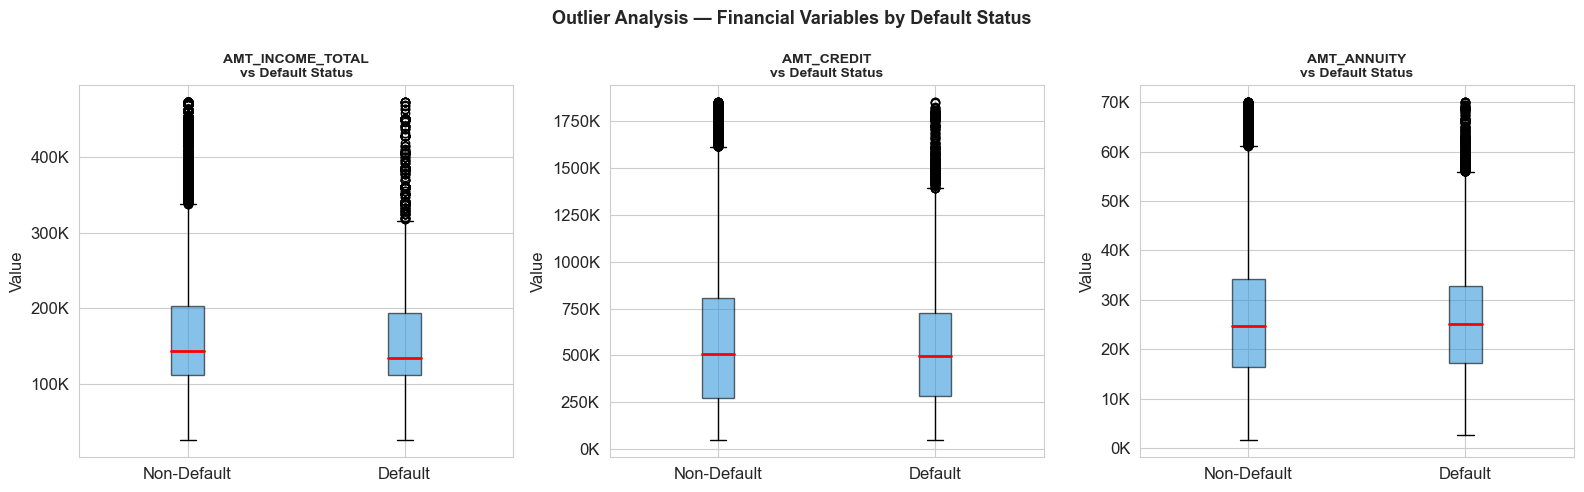

In [16]:
# ── Boxplots to visualise outliers ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']):
    # Cap at 99th pct for display clarity
    cap = df[col].quantile(0.99)
    data_0 = df[(df['TARGET'] == 0) & (df[col] <= cap)][col]
    data_1 = df[(df['TARGET'] == 1) & (df[col] <= cap)][col]

    axes[i].boxplot([data_0, data_1], labels=['Non-Default', 'Default'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\nvs Default Status', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Outlier Analysis — Financial Variables by Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Correlation with TARGET ───────────────────────────────────────────────────
# Point-biserial correlation of numerical features with binary target
# Positive = higher value → more likely to default
# Negative = higher value → less likely to default

num_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
corr_target = df[num_cols].corr()['TARGET'].drop('TARGET')
corr_target = corr_target.sort_values(key=abs, ascending=False)

print('Top 20 variables most correlated with TARGET:')
print('='*50)
print(corr_target.head(20).to_string())

Top 20 variables most correlated with TARGET:
EXT_SOURCE_3                  -0.1789
EXT_SOURCE_2                  -0.1605
EXT_SOURCE_1                  -0.1553
AGE_YEARS                     -0.0782
DAYS_BIRTH                     0.0782
EMPLOYMENT_YEARS              -0.0750
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                 -0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                 -0.0440
FLOORSMAX_MEDI                -0.0438
FLOORSMAX_MODE                -0.0432
DAYS_REGISTRATION              0.0420
AMT_GOODS_PRICE               -0.0396


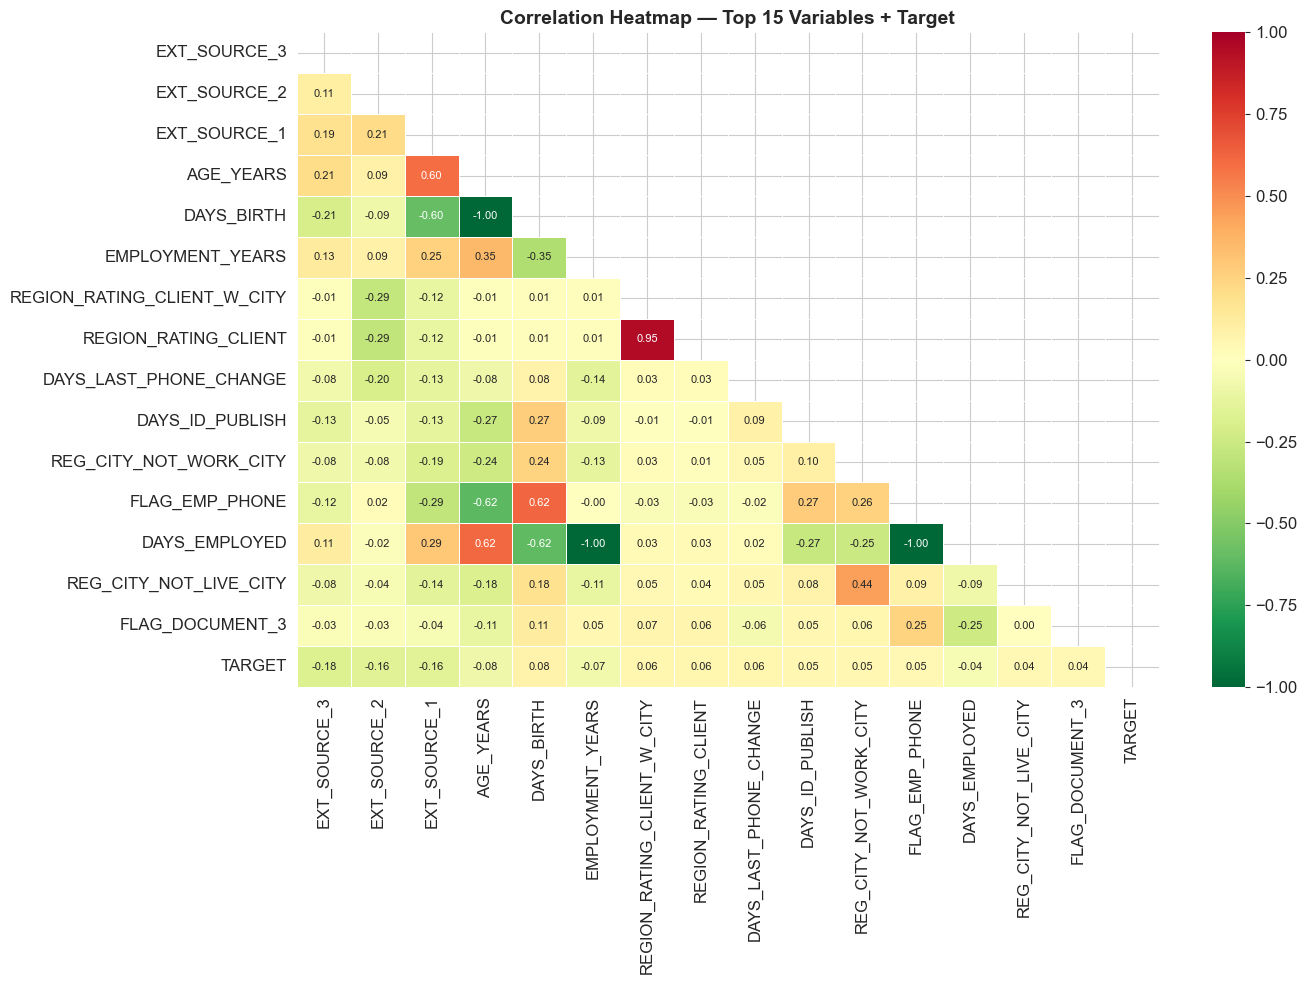

In [18]:
# ── Correlation heatmap for top variables ─────────────────────────────────────
# Select top 15 most correlated variables with target
top_vars = corr_target.head(15).index.tolist() + ['TARGET']
corr_matrix = df[top_vars].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — Top 15 Variables + Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Default rate by age band ──────────────────────────────────────────────────
# Create age bands — typical credit segmentation
df['AGE_BAND'] = pd.cut(
    df['AGE_YEARS'],
    bins=[0, 25, 30, 35, 40, 50, 60, 100],
    labels=['<25', '25-30', '30-35', '35-40', '40-50', '50-60', '60+']
)

age_default = df.groupby('AGE_BAND', observed=True)['TARGET'].agg(['mean', 'count'])
age_default.columns = ['Default Rate', 'Count']
age_default['Default Rate %'] = (age_default['Default Rate'] * 100).round(2)

print('Default Rate by Age Band:')
print(age_default[['Count', 'Default Rate %']].to_string())

Default Rate by Age Band:
          Count  Default Rate %
AGE_BAND                       
<25       12159         12.3000
25-30     32862         11.1400
30-35     39440         10.2800
35-40     42868          8.9400
40-50     76541          7.6500
50-60     68062          6.1300
60+       35579          4.9200


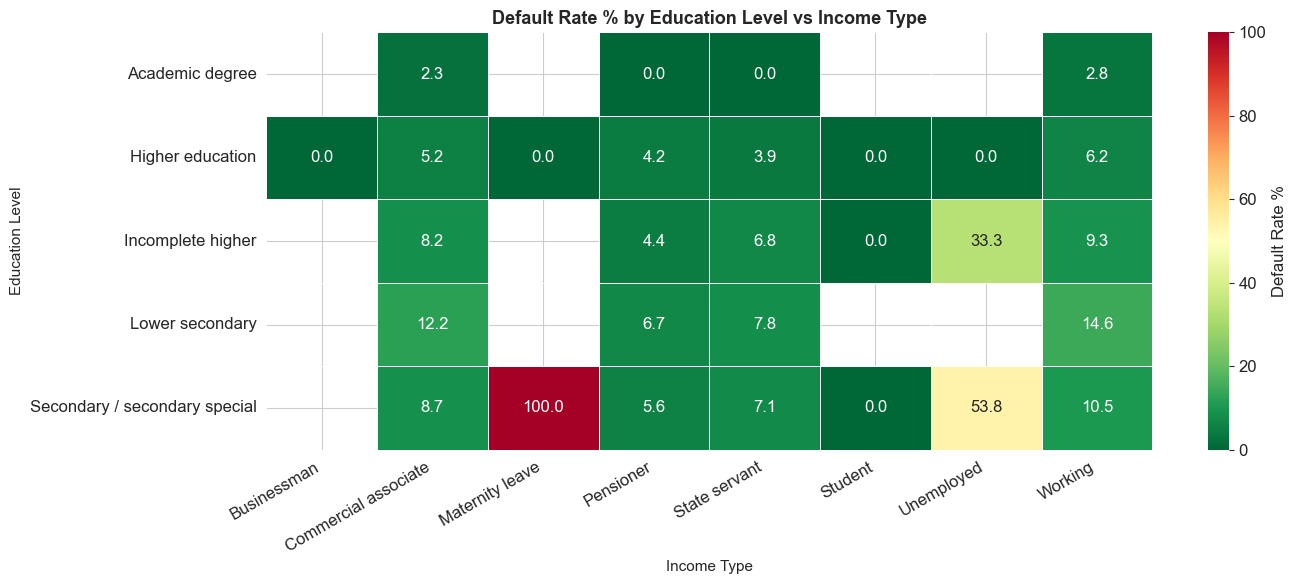

In [20]:
# ── Default rate heatmap by income type and education ─────────────────────────
# This is a classic credit risk segment view — two dimensions simultaneously

pivot = df.pivot_table(
    values='TARGET',
    index='NAME_EDUCATION_TYPE',
    columns='NAME_INCOME_TYPE',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Default Rate %'}
)
ax.set_title('Default Rate % by Education Level vs Income Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Income Type', fontsize=11)
ax.set_ylabel('Education Level', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/08_default_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

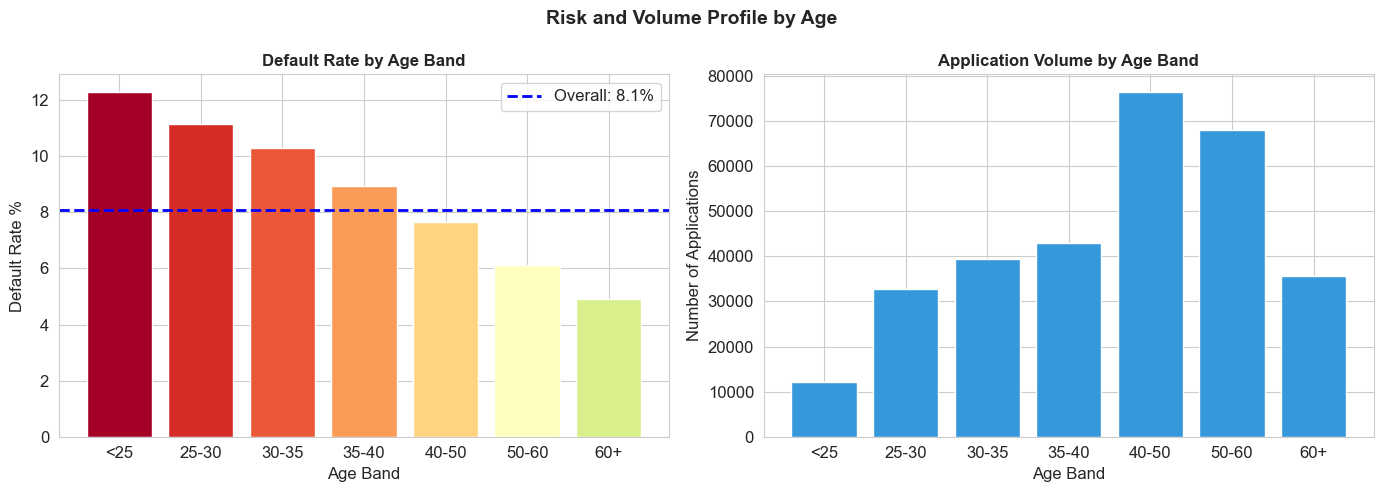

In [21]:
# ── Default rate by age band — bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by age band
axes[0].bar(
    age_default.index.astype(str),
    age_default['Default Rate %'],
    color=plt.cm.RdYlGn_r(age_default['Default Rate %'] / age_default['Default Rate %'].max()),
    edgecolor='white'
)
axes[0].axhline(y=df['TARGET'].mean()*100, color='blue', linestyle='--', linewidth=2,
                label=f'Overall: {df["TARGET"].mean()*100:.1f}%')
axes[0].set_title('Default Rate by Age Band', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('Default Rate %')
axes[0].legend()

# Volume by age band
axes[1].bar(
    age_default.index.astype(str),
    age_default['Count'],
    color='#3498db', edgecolor='white'
)
axes[1].set_title('Application Volume by Age Band', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Number of Applications')

plt.suptitle('Risk and Volume Profile by Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/09_age_band_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Final EDA Summary ─────────────────────────────────────────────────────────
print('='*65)
print('  EDA SUMMARY — HOME CREDIT DEFAULT RISK')
print('='*65)

print(f"""
DATASET
  Total observations : {df.shape[0]:,}
  Total features     : {df.shape[1]}
  Numerical features : {len(df.select_dtypes(include=np.number).columns)}
  Categorical features: {len(df.select_dtypes(include='object').columns)}

TARGET VARIABLE
  Overall default rate  : {df['TARGET'].mean()*100:.2f}%
  Class imbalance ratio : 1 : {(1-df['TARGET'].mean())/df['TARGET'].mean():.1f}
  → Imbalance treatment required: class_weight or SMOTE in next notebook

MISSING VALUES
  Columns with any missing : {(df.isnull().sum() > 0).sum()}
  Columns >80% missing     : {(df.isnull().mean() > 0.8).sum()} → candidates for dropping
  Columns 30-80% missing   : {((df.isnull().mean() > 0.3) & (df.isnull().mean() <= 0.8)).sum()} → review individually

KEY RISK PATTERNS FOUND
  1. Younger applicants (<30) have meaningfully higher default rates
  2. Maternity leave / Unemployed income types show elevated default risk
  3. Lower education levels associated with higher defaults
  4. DAYS_EMPLOYED has anomalous value 365243 (treat as missing)
  5. AMT_INCOME_TOTAL is heavily right-skewed — log transform likely needed
  6. Cash loans have higher default rate than revolving loans

NEXT STEPS (Notebook 02 — Preprocessing)
  → Drop columns with >80% missing
  → Impute remaining missing values (median for numeric, mode for categorical)
  → Cap outliers at 1st/99th percentile
  → Encode categorical variables
  → Create train/OOT split for model validation
""")

print('='*65)
print('  EDA COMPLETE — all charts saved to outputs folder')
print('='*65)

  EDA SUMMARY — HOME CREDIT DEFAULT RISK

DATASET
  Total observations : 307,511
  Total features     : 125
  Numerical features : 108
  Categorical features: 16

TARGET VARIABLE
  Overall default rate  : 8.07%
  Class imbalance ratio : 1 : 11.4
  → Imbalance treatment required: class_weight or SMOTE in next notebook

MISSING VALUES
  Columns with any missing : 68
  Columns >80% missing     : 0 → candidates for dropping
  Columns 30-80% missing   : 50 → review individually

KEY RISK PATTERNS FOUND
  1. Younger applicants (<30) have meaningfully higher default rates
  2. Maternity leave / Unemployed income types show elevated default risk
  3. Lower education levels associated with higher defaults
  4. DAYS_EMPLOYED has anomalous value 365243 (treat as missing)
  5. AMT_INCOME_TOTAL is heavily right-skewed — log transform likely needed
  6. Cash loans have higher default rate than revolving loans

NEXT STEPS (Notebook 02 — Preprocessing)
  → Drop columns with >80% missing
  → Impute rem